<a href="https://colab.research.google.com/github/TecLevel01/cloth-classification/blob/train-ai/fashion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Project Structure:**

Cloth Classification :
|
data
|
notebooks
|
models
|
src
|
main.py

In [ ]:
import pandas as pnd
import numpy as np
from google.colab import drive
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

STEP 1 :DATA PREPARATION

In [ ]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
data_path = '/content/drive/MyDrive/fashionClassifacation/data_set'

1.1 LOAD DATA

In [ ]:
training_data = pnd.read_csv(data_path + '/fashion-mnist_train.csv')
testing_data = pnd.read_csv(data_path + '/fashion-mnist_test.csv')

In [ ]:
training_data.shape

(60000, 785)

In [ ]:
testing_data.shape

(10000, 785)

In [ ]:
training_data.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
training_data.columns

Index(['label', 'pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5', 'pixel6',
       'pixel7', 'pixel8', 'pixel9',
       ...
       'pixel775', 'pixel776', 'pixel777', 'pixel778', 'pixel779', 'pixel780',
       'pixel781', 'pixel782', 'pixel783', 'pixel784'],
      dtype='object', length=785)

In [ ]:
testing_data.columns

Index(['label', 'pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5', 'pixel6',
       'pixel7', 'pixel8', 'pixel9',
       ...
       'pixel775', 'pixel776', 'pixel777', 'pixel778', 'pixel779', 'pixel780',
       'pixel781', 'pixel782', 'pixel783', 'pixel784'],
      dtype='object', length=785)

1.2 : SPLIT FEATURES & LABELS

In [ ]:
x_training = training_data.iloc[:, 1:].values
y_training = training_data.iloc[:, 0].values

x_testing = testing_data.iloc[:, 1:].values
y_testing = testing_data.iloc[:, 0].values

1.3 : DATA NORMALIZATION

In [ ]:
x_training = x_training / 255.0
x_testing = x_testing / 255.0

1.4: VISUALIZE SAMPLES

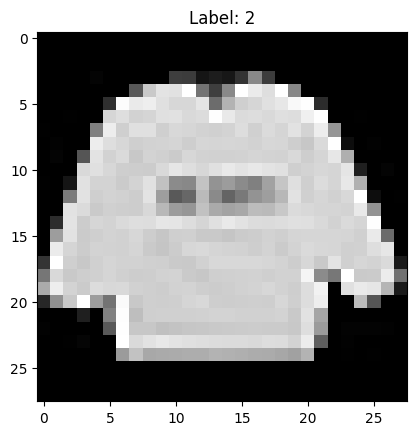

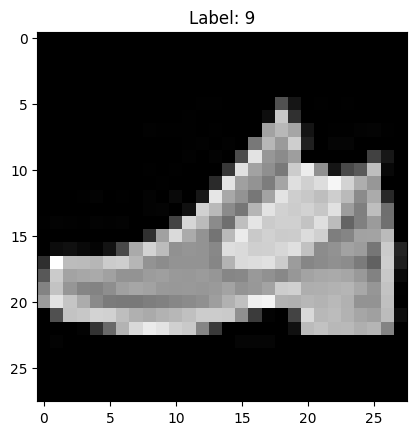

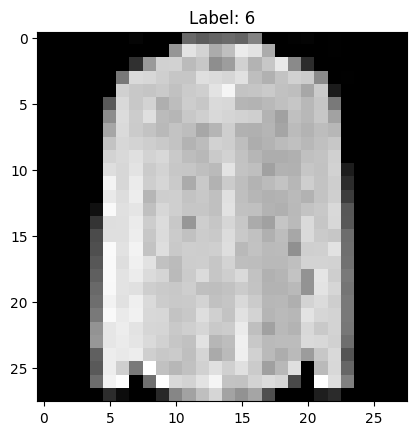

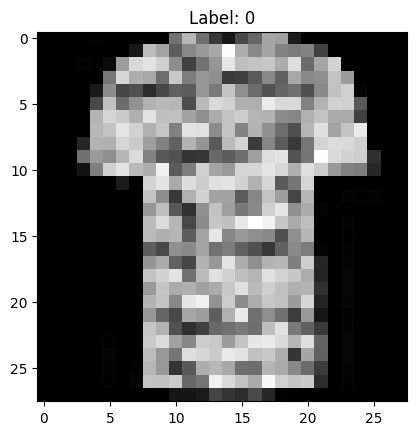

In [ ]:
for i in range(4):
  plt.imshow(x_training[i].reshape(28,28), cmap = 'gray')
  plt.title(f'Label: {y_training[i]}')
  plt.show()

STEP 2: BASELINE MODEL (<small>Logistic Regression</small>)

2.1 Training

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
model_lr = LogisticRegression(max_iter = 1000)
model_lr.fit(x_training, y_training)

LogisticRegression(max_iter=1000)

2.2 Evaluation

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix

In [ ]:
y_predict = model_lr.predict(x_testing)
print('LR Accurancy: ', accuracy_score(y_testing, y_predict))

LR Accurancy:  0.8541


STEP 3: PREPARE DATA FOR CNN

In [ ]:
x_training_cnn = x_training.reshape(-1, 28, 28, 1)
x_testing_cnn = x_testing.reshape(-1, 28, 28, 1)

STEP 4: BUILD CNN MODEL

4.1 DEFINE MODEL

In [ ]:
from tensorflow.keras import models, layers, Input

In [ ]:
cnn_model = models.Sequential([
    Input(shape = (28,28,1)),

    layers.Conv2D(32,(3,3), activation = 'relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3,3), activation = 'relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    layers.Conv2D(128, (3,3), activation = 'relu'),
    layers.BatchNormalization(),

    layers.Flatten(),
    layers.Dense(128, activation = 'relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation = 'softmax')

])

STEP 5: COMPILE

Before training, you must configure how the model learns.
Think of it like setting rules: “How should the model update itself when it's wrong?” *italicized text*

In [ ]:
cnn_model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

## This step was add after runing the CM (STEP:8) for improving the model after seing the CM
STEP 9 : DATA AUGMENTATION

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
dataGen = ImageDataGenerator(
    rotation_range = 10,
    zoom_range = 0.1
)

STEP 5: TRAIN CNN

In [ ]:
#-------------My old training code before learning about data augmentation---------#

# history_train = cnn_model.fit(
#     x_training_cnn, y_training,
#     epochs = 10,
#     batch_size = 32,
#     validation_split = 0.1

# )

#------------The new version of the code after learning about data augmentation-----#

history_train = cnn_model.fit(
    dataGen.flow(x_training_cnn, y_training, batch_size = 32),
    epochs = 10,
    validation_data = (x_testing_cnn, y_testing)
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 120s 62ms/step - accuracy: 0.7698 - loss: 0.6405 - val_accuracy: 0.8355 - val_loss: 0.4384
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 117s 63ms/step - accuracy: 0.8296 - loss: 0.4652 - val_accuracy: 0.8860 - val_loss: 0.3041
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 116s 62ms/step - accuracy: 0.8471 - loss: 0.4149 - val_accuracy: 0.8773 - val_loss: 0.3249
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 119s 63ms/step - accuracy: 0.8575 - loss: 0.3907 - val_accuracy: 0.8965 - val_loss: 0.2790
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 117s 63ms/step - accuracy: 0.8661 - loss: 0.3709 - val_accuracy: 0.8917 - val_loss: 0.2864
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 116s 62ms/step - accuracy: 0.8696 - loss: 0.3568 - val_accuracy: 0.8929 - val_loss: 0.2821
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 117s 62ms/step - accuracy: 0.8736 - loss: 0.3467 - val_accuracy: 0.8866 - val_loss: 0.3007
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 142s 62ms/step - accuracy: 

STEP 6: EVALUATE CNN

<Axes: >

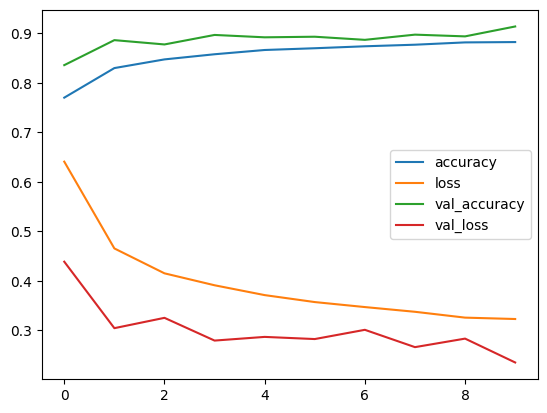

In [ ]:
pnd.DataFrame(history_train.history).plot()

In [ ]:
test_loss, test_accuracy = cnn_model.evaluate(x_testing_cnn, y_testing)
print('CNN Accuracy: ', test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.9136 - loss: 0.2348
CNN Accuracy:  0.9136000275611877


STEP 7: We compare the LOGISTIC REGRESSION VS CNN (85% VS 91%)
        CNN is better because of its capability of understanding images as images rather than just some simple numbers.

        This step teaches us that choosing the right model mattters more than just training

STEP 8: CONFUSION MATRIX

In [ ]:
##confusion_matrix already imported above
import seaborn as sbn

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step


<Axes: >

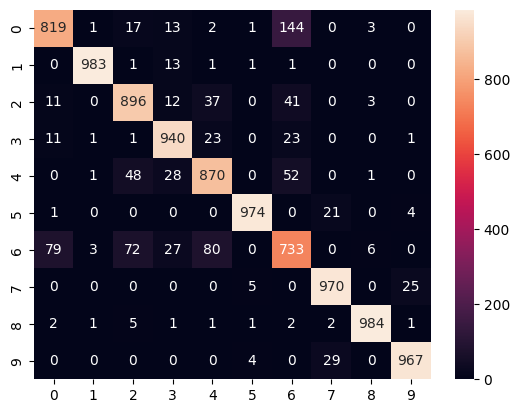

In [ ]:
y_predict_cnn = cnn_model.predict(x_testing_cnn).argmax(axis = 1)
cm_data = confusion_matrix(y_testing, y_predict_cnn)
sbn.heatmap(cm_data, annot = True, fmt = 'd')

STEP 10: SAVING & LOADING THE MODEL

        It saves your trained CNN so you can:

        Use it later without retraining
        Deploy it in an app
        Share it with others

In [ ]:
cnn_model.save('/content/drive/MyDrive/fashionClassifacation/fashion_cnn.keras')

In [ ]:
from tensorflow.keras.models import load_model

In [ ]:
cnn_model = load_model('/content/drive/MyDrive/fashionClassifacation/fashion_cnn.keras')

STEP 11: BUILD A PREDICTION FUNCTION

In [ ]:
label_map = {
    0: 'T-shirt/top',
    1: 'Trouser',
    2: 'Pullover',
    3: 'Dress',
    4: 'Coat',
    5: 'Sandal',
    6: 'Shirt',
    7: 'Sneaker',
    8: 'Bag',
    9: 'Ankle boot'
    }

In [ ]:
def predict_image(cnn_model, image):
  image = image.reshape(1,28,28,1)
  pred = cnn_model.predict(image) # Changed 'model' to 'cnn_model'
  class_index = np.argmax(pred)
  confidence = pred[0][class_index]
  return label_map[class_index], confidence

In [ ]:
label_map, confidence = predict_image(cnn_model, x_testing[3])
print(f'Predicted: {label_map}, Confidence: {confidence}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step
Predicted: Shirt, Confidence: 0.5468614101409912


In [ ]:
#Show rows with at least one null value
# training_data[training_data.isnull().any(axis=1)]

In [ ]:
# #Show columns that contain at least one null value
# training_data.loc[:, training_data.isnull().any(axis=0)]

In [ ]:
# training_data['label']

In [ ]:
# training_data.loc[~training_data['label'].duplicated(keep=False), 'label']

In [ ]:
# myLabel_column = list(dict.fromkeys(training_data['label']))
# myLabel_column

In [ ]:
# myLabel_column = sorted(myLabel_column)
# myLabel_column

In [ ]:
# img001 = training_data.iloc[0].drop('label').values.astype(float)
# img001 = img001.reshape(28,28)
# print(img001.dtype)

In [ ]:
# !unzip /content/drive/MyDrive/fashionClassifacation/data_set/t10k-images-idx3-ubyte

